## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [58]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


base_path = "/Users/kdt_0900_cjs/ml/resource/dataset"
file_name = "social_ads.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 데이터 전처리

In [59]:
# UserID :삭제
# 수치형 : Age, EstimatedSalary 
# 분류형 : User ID, gender, Purchased
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [60]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [61]:
ads_df = df.drop("User ID", axis = 1)
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [62]:
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

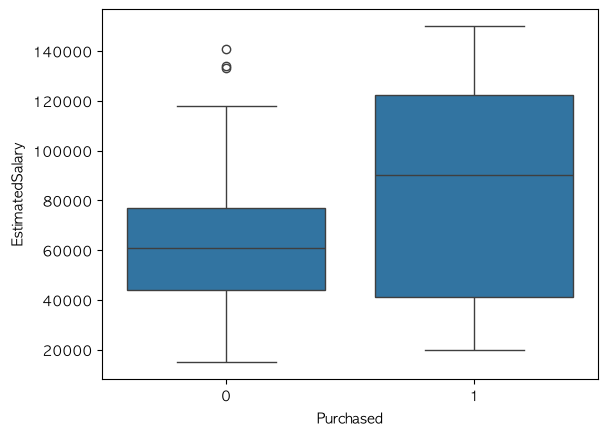

In [63]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

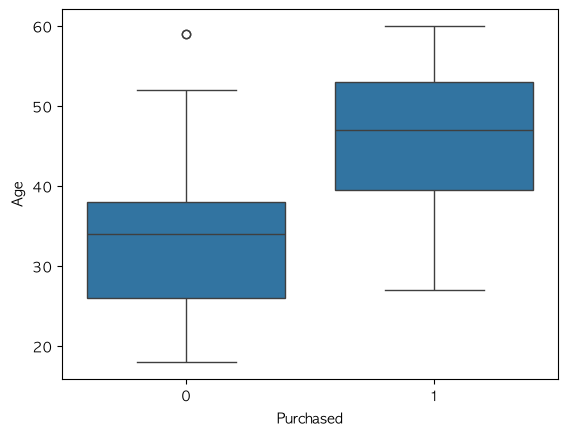

In [64]:
sns.boxplot(ads_df, x="Purchased", y="Age")
plt.show()

In [65]:
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [66]:
ads_df = pd.get_dummies(ads_df, columns=["Gender"], dtype=int,drop_first=True)

In [67]:
ads_df.head()

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,0,0
3,27,57000,0,0
4,19,76000,0,1


In [68]:
X = ads_df.drop("Purchased", axis = 1)
X.head(1)

,Age,EstimatedSalary,Gender_Male
0,19,19000,1


In [69]:
y=  ads_df["Purchased"]
y.head(1)

0    0
Name: Purchased, dtype: int64

In [70]:
X.columns=["Age", "Salary", "Gender"]

In [71]:
X.head()

,Age,Salary,Gender
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


## 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유 -> 데이터 셋을 나누기 전에 전체 데이터를 스케일링하면  
    모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련데이터 셋에 야금야금 스며들어서 데이터 누수가 발생한다.

In [72]:
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2단계, 모델 준비

In [73]:
#Salary 연봉
X_train_Salary = X_train_scaled[:, [1]]
X_train_salary = X_test_scaled[:, [1]]

In [74]:
# 선형회귀 모델(weight * x) + b(bias) 
lr = LinearRegression()

In [75]:
lr.fit(X_train_Salary, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.18]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3563
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[17.89]


In [76]:
print(f"선형모델의 정답 : {lr.score(X_train_Salary, y_train)}")

선형모델의 정답 : 0.1408930349620513


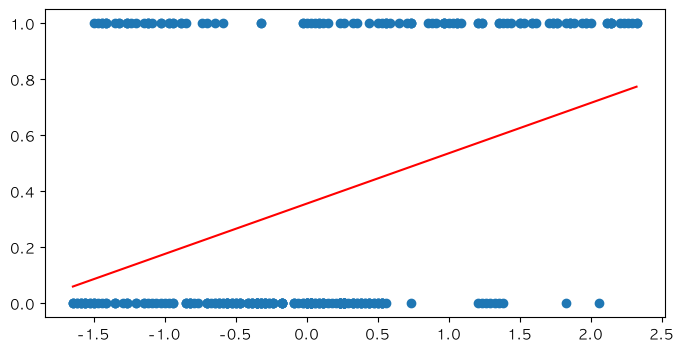

In [77]:
plt.figure(figsize=(8,4))
plt.scatter(X_train_Salary, y_train)
x_line = np.linspace(X_train_Salary.min(), X_train_Salary.max(), 100).reshape(-1, 1)
y_line = lr.predict(x_line)

plt.plot(x_line, y_line, color="red")
plt.show()

## 모델 준비

In [78]:
lr = LogisticRegression()

## 모델 학습

In [79]:
lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [80]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0])

## 모델 평가

In [81]:
print(f"훈련 데이터 점수 : {lr.score(X_train_scaled, y_train)}")
print(f"테스트 데이터 점수 : {accuracy_score(y_test, y_pred)}")


훈련 데이터 점수 : 0.853125
테스트 데이터 점수 : 0.7875


## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

## 과적합
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화 되는 현상을 의미합니다  
  현재 데이터셋에 지나치게 맞춰지면 새로운 데이터가 들어왓을때 예측 능력이 크게 떨어질 수 있습니다.  
  이런 현상을 과적합이라고 합니다

In [82]:
coef_df = pd.DataFrame({
    "Features" : X_train.columns,
    "Coef" : lr.coef_[0],
    
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
0,Age,2.394875
1,Salary,1.161530
2,Gender,0.373889


In [83]:
"""
    소셜에서 상품을 구매할 때에는 연봉보다느 ㄴ나이가 구매할 때의 영향을 많이 끼친 것으로 파악된다
"""
None

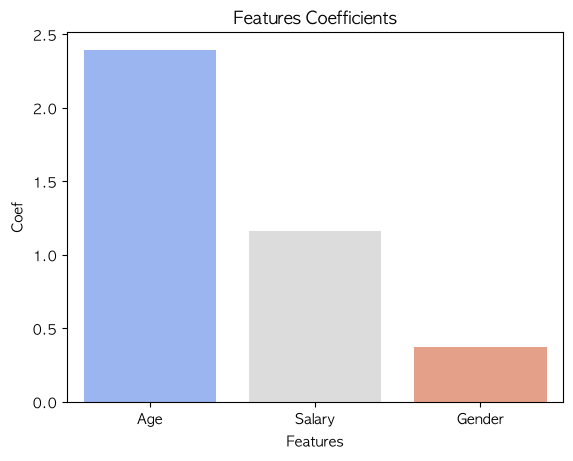

In [84]:
sns.barplot(coef_df, x="Features", y="Coef", hue = "Features", palette="coolwarm")
plt.title("Features Coefficients")
plt.show()

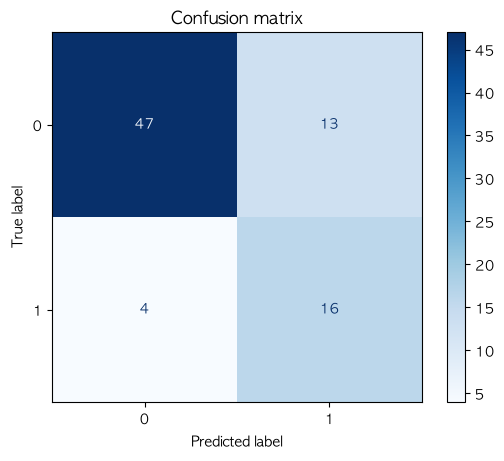

In [86]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [88]:
base_path = "/Users/kdt_0900_cjs/ml/resource/dataset"
file_name = "admission_predict.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0
